In [2]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
import sys
import numpy as np
from DVAE import VAE
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import sklearn.cluster as skl_cluster
from sklearn import manifold, decomposition, datasets
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.cluster import SpectralClustering
import statistics
import matplotlib.patches as mpatches
import glob
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm 

2025-07-30 15:47:37.647201: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-30 15:47:37.685540: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753904857.715662 3284533 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753904857.724839 3284533 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753904857.746593 3284533 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
#  Configuration 
data_dir = "training128"
MAX_FILES = 2
BATCH_SIZE = 100  # number of files per batch
OUTPUT_FILE = "good16.2_batched.npy"
DTYPE = np.int8  

#  Get and filter filenames 
file_list = sorted([
    f for f in os.listdir(data_dir)
    if os.path.isfile(os.path.join(data_dir, f))
])[:MAX_FILES]

#  Determine shape by peeking into the first valid line 
for fname in file_list:
    with open(os.path.join(data_dir, fname), 'r') as f:
        for line in f:
            if line.strip():
                sample_shape = len(line.strip().split())
                break
    if sample_shape:
        break

print("Scanning file line counts...")
total_lines = 0
line_counts = []
for fname in file_list:
    count = sum(1 for _ in open(os.path.join(data_dir, fname)))
    line_counts.append(count)
    total_lines += count

print(f"Estimated total lines: {total_lines}")

#  Preallocate output array using memmap 
out_array = np.lib.format.open_memmap(
    OUTPUT_FILE,
    mode='w+',
    dtype=DTYPE,
    shape=(total_lines, sample_shape)
)

#  Process files in batches 
cursor = 0
for i in range(0, len(file_list), BATCH_SIZE):
    batch_files = file_list[i:i + BATCH_SIZE]
    batch_data = []

    for fname in batch_files:
        with open(os.path.join(data_dir, fname), 'r') as f:
            for line in f:
                try:
                    values = [int(x) for x in line.strip().split()]
                    if len(values) == sample_shape:
                        batch_data.append(values)
                except ValueError:
                    print(f"Skipping bad line in {fname}: {line!r}")

    batch_data = np.array(batch_data, dtype=DTYPE)
    out_array[cursor:cursor + len(batch_data)] = batch_data
    cursor += len(batch_data)

    print(f"Processed {i + len(batch_files)} / {len(file_list)} files...")

print(f"\nFinal saved shape: {out_array.shape}")
print(f"Saved to: {OUTPUT_FILE}")


Scanning file line counts...
Estimated total lines: 108
Processed 2 / 2 files...

Final saved shape: (108, 16384)
Saved to: good16.2_batched.npy


In [5]:
data = np.load("good16.2_batched.npy")

In [7]:
#VAE expect images so we need to unflatten the data
flat_data = data
side_length = int(data.shape[1]**0.5)
data = data.reshape(-1, side_length, side_length)  # Shape: (4000, 32, 32)
# np.savetxt("ising_dataset.txt", data.reshape(data.shape[0], -1), delimiter=',')
print(data.shape)

(108, 128, 128)


In [7]:
model_path = "new16.3.keras"
vae = VAE(load=model_path)

I0000 00:00:1753800268.916318 2884781 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1753800268.916492 2884781 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14775 MB memory:  -> device: 0, name: Quadro RTX 5000, pci bus id: 0000:9e:00.0, compute capability: 7.5
/home/lledson/.conda/envs/myenv/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


ValueError: A total of 7 objects could not be loaded. Example error message for object <Dense name=dense_1, built=True>:

Layer 'dense_1' expected 2 variables, but received 0 variables during loading. Expected: ['kernel', 'bias']

List of objects that could not be loaded:
[<Dense name=dense_1, built=True>, <Conv2DTranspose name=conv2d_transpose, built=True>, <Conv2DTranspose name=conv2d_transpose_1, built=True>, <Conv2DTranspose name=conv2d_transpose_2, built=True>, <Conv2D name=conv2d, built=True>, <Conv2D name=conv2d_1, built=True>, <Dense name=dense, built=True>]

I0000 00:00:1753731172.479874 2656293 cuda_dnn.cc:529] Loaded cuDNN version 90300


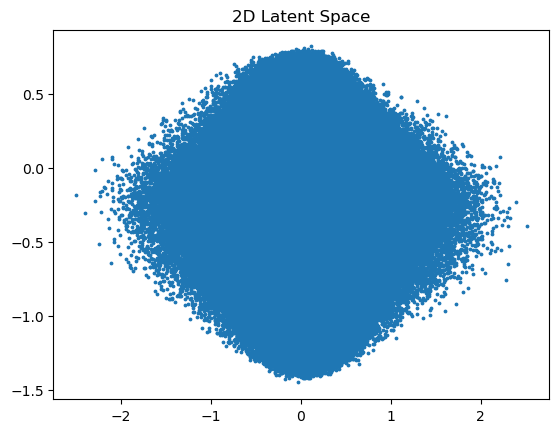

In [5]:
batch_size = 128
means_list = []
logvars_list = []

for i in range(0, len(data), batch_size):
    batch = data[i:i + batch_size]
    m, l = vae.encode(batch, both=True)
    means_list.append(m)
    logvars_list.append(l)

means = np.concatenate(means_list, axis=0)
logvars = np.concatenate(logvars_list, axis=0)

np.save("latent_means_good256.1.npy", means)
np.save("latent_logvars_good256.1.npy", logvars)

# Plot the 2D latent space
plt.scatter(means[:, 0], means[:, 1], s=3)
plt.title("2D Latent Space")
plt.show()

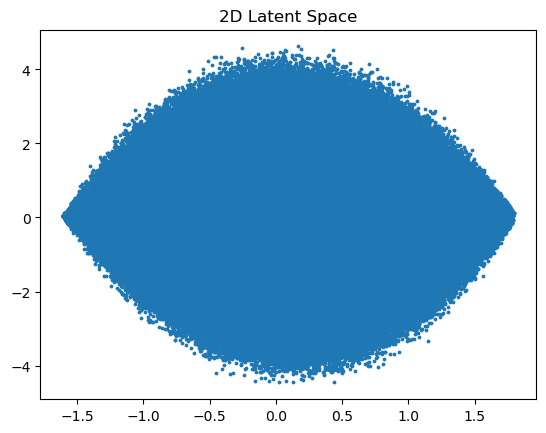

In [2]:
means = np.load("latent_means_good16.1.npy")
logvars =np.load("latent_logvars_good16.1.npy")

# Plot the 2D latent space
plt.scatter(means[:, 0], means[:, 1], s=3)
plt.title("2D Latent Space")
plt.show()

In [3]:
#temp list for good 16x16

temperature_list = [2.050, 2.065, 2.080, 2.095, 2.110, 2.125, 2.140, 2.155, 2.170, 2.185, 2.200, 2.215, 
                    2.230, 2.245, 2.260, 2.275, 2.290, 2.305, 2.320, 2.335, 2.350, 2.365, 2.380, 2.395, 
                    2.410, 2.425, 2.440, 2.455, 2.470, 2.485, 2.500, 2.515, 2.530, 2.545, 2.560, 2.575, 
                    2.590, 2.605, 2.620, 2.635, 2.650, 2.665, 2.680, 2.695, 2.710, 2.725, 2.740, 2.755, 
                    2.770, 2.785]
print(len(temperature_list))

50


In [6]:
#temp list for good 32x32 

temperature_list = [
    2.1278, 2.1364, 2.1451, 2.1537, 2.1623, 2.1709, 2.1795, 2.1881, 2.1967, 2.2053,
2.2139, 2.2225, 2.2311, 2.2397, 2.2483, 2.2569, 2.2655, 2.2741, 2.2827, 2.2913,
2.2999, 2.3085, 2.3171, 2.3257, 2.3343, 2.3429, 2.3515, 2.3601, 2.3687, 2.3773,
2.3859, 2.3945, 2.4031, 2.4117, 2.4203, 2.4289, 2.4375, 2.4461, 2.4547, 2.4633,
2.4719, 2.4805, 2.4891, 2.4977, 2.5063, 2.5149, 2.5235, 2.5321, 2.5407, 2.5493
]
print(len(temperature_list))

50


In [43]:
#temp lis for good 64x64
temperature_list = [
    2.208, 2.21228571, 2.21657143, 2.22085714, 2.22514286, 2.22942857, 2.23371429,
    2.238, 2.24228571, 2.24657143, 2.25085714, 2.25514286, 2.25942857, 2.26371429,
    2.268, 2.27228571, 2.27657143, 2.28085714, 2.28514286, 2.28942857, 2.29371429,
    2.298, 2.30228571, 2.30657143, 2.31085714, 2.31514286, 2.31942857, 2.32371429,
    2.328, 2.33228571, 2.33657143, 2.34085714, 2.34514286, 2.34942857, 2.35371429,
    2.358, 2.36228571, 2.36657143, 2.37085714, 2.37514286, 2.37942857, 2.38371429,
    2.388, 2.39228571, 2.39657143, 2.40085714, 2.40514286, 2.40942857, 2.41371429,
    2.418
]
print(len(temperature_list))

50


In [14]:
#temp list for good 128x128

temperature_list = [ 2.2310, 2.2338, 2.2366, 2.2395, 2.2423, 2.2451, 2.2480, 2.2508, 2.2536, 2.2565,
2.2593, 2.2621, 2.2650, 2.2678, 2.2706, 2.2735, 2.2763, 2.2791, 2.2820, 2.2848,
2.2876, 2.2905, 2.2933, 2.2961, 2.2990, 2.3018, 2.3046, 2.3075, 2.3103, 2.3131,
2.3160, 2.3188, 2.3216, 2.3245, 2.3273, 2.3301, 2.3330, 2.3358, 2.3386, 2.3415,
2.3443, 2.3471, 2.3500, 2.3528, 2.3556, 2.3585, 2.3613, 2.3641, 2.3670, 2.3690
]
print(len(temperature_list))

50


In [6]:
#temp list for good 256x256

temperature_list =  [2.235147534,2.236930345,2.238713157,2.240495968,2.242278779,2.244061591,2.245844402,2.247627213,2.249410025,2.251192836,2.252975647,2.254758459,2.256541270,2.258324081,2.260106893,2.261889704,2.263672515,2.265455327,2.267238138,2.269020949,2.270803761,2.272586572,2.274369383,2.276152195,2.277935006,2.279717817,2.281500629,2.283283440,2.285066251,2.286849063,2.288631874,2.290414685,2.292197497,2.293980308,2.295763119,2.297545931,2.299328742,2.301111553,2.302894365,2.304677176,2.306459987,2.308242799,2.310025610,2.311808421,2.313591233,2.315374044,2.317156855,2.318939667,2.320722478,2.322505289]
print(len(temperature_list))

50


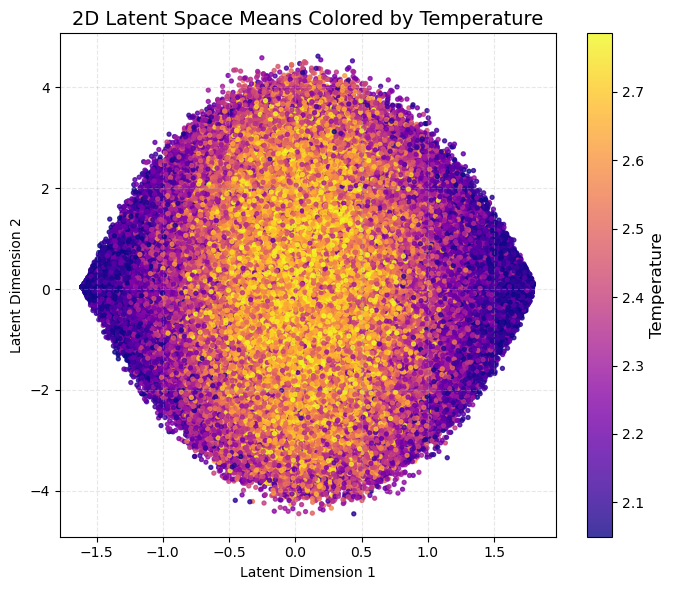

In [14]:
temperature_labels = temperature_list * (len(means) // len(temperature_list))

# pca = PCA(n_components=2)
# pca_result = pca.fit_transform(means)
pca_result = means 

plt.figure(figsize=(7, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=temperature_labels, cmap='plasma', s=8, alpha=0.8)
cbar = plt.colorbar(scatter)
cbar.set_label("Temperature", fontsize=12)

plt.title("2D Latent Space Means Colored by Temperature", fontsize=14)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [4]:
# Compute magnetization = sum of spins per config
magnetizations = np.sum(flat_data, axis=1)

# Assign temperature labels
temperature_labels = temperature_list * (len(means) // len(temperature_list))
temperature_labels = np.array(temperature_labels)

np.save("temperature_labels_good16.2.npy", temperature_labels)
np.save("magnetizations_good16.2.npy", magnetizations)


# Color outline: green if T > 2.3, blue otherwise
outline_colors = np.where(temperature_labels > 2.3, 'red', 'green')

# Plot
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    pca_result[:, 0], pca_result[:, 1],
    c=magnetizations,
    cmap='plasma',
    edgecolors=outline_colors,
    linewidths=0.5,
    s=14,
    alpha=0.8,
)

legend_patches = [
    mpatches.Patch(edgecolor='green', facecolor='white', label='T < 2.3', linewidth=1.5),
    mpatches.Patch(edgecolor='red', facecolor='white', label='T > 2.3', linewidth=1.5),
]
plt.legend(handles=legend_patches, loc='upper left', title='Temperature Range')


cbar = plt.colorbar(scatter)
cbar.set_label("Magnetization (sum of spins)", fontsize=12)

plt.title("2D Latent Space Means Colored by Magnetization with PCA", fontsize=14)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'flat_data' is not defined

In [48]:
# Assign temperature labels
temperature_labels = temperature_list * 2500000
temperature_labels = np.array(temperature_labels)
magnetizations = np.sum(flat_data, axis=1)

np.save("temperature_labels_good64.1.npy", temperature_labels)
np.save("magnetizations_good64.1.npy", magnetizations)

In [9]:
#  Configuration 
output_dir = "overlap_batches_test32.1"
os.makedirs(output_dir, exist_ok=True)

# Prep for Overlap 
fitImgsVAE = means.astype(np.float32)
fitImgsSTD = np.exp(logvars) ** 0.5
fitImgsSTD = fitImgsSTD.astype(np.float32)

#  Overlap Function 
def compute_overlap_matrix(mu, sigma):
    mu_i = mu[:, None]
    mu_j = mu[None, :]
    sigma_i = sigma[:, None]
    sigma_j = sigma[None, :]
    
    sigma_sq_sum = sigma_i ** 2 + sigma_j ** 2
    coef = (2 * sigma_i * sigma_j) / sigma_sq_sum
    exponent = -((mu_i - mu_j) ** 2) / (4 * sigma_sq_sum)
    return (coef * np.exp(exponent)).astype(np.float32)

#  Batch Processing 
num_samples = fitImgsVAE.shape[0]
batch_size = 5000
num_batches = int(np.ceil(num_samples / batch_size))

for i in range(num_batches):
    start = i * batch_size
    end = min((i + 1) * batch_size, num_samples)

    mu_batch = fitImgsVAE[start:end]
    sigma_batch = fitImgsSTD[start:end]

    print(f"Processing batch {i+1}/{num_batches}: samples {start} to {end-1}")

    # 2D product of latent overlaps
    overlap_dim0 = compute_overlap_matrix(mu_batch[:, 0], sigma_batch[:, 0])
    overlap_dim1 = compute_overlap_matrix(mu_batch[:, 1], sigma_batch[:, 1])
    overlap = overlap_dim0 * overlap_dim1

    # Save matrix (no batch variable saved inside—just the raw matrix)
    out_path = os.path.join(output_dir, f"overlap_batch_{i}.npy")
    np.save(out_path, overlap)

print(f"\nDone. Overlap matrices saved to: {output_dir}/")


Processing batch 1/50: samples 0 to 4999
Processing batch 2/50: samples 5000 to 9999
Processing batch 3/50: samples 10000 to 14999
Processing batch 4/50: samples 15000 to 19999
Processing batch 5/50: samples 20000 to 24999
Processing batch 6/50: samples 25000 to 29999
Processing batch 7/50: samples 30000 to 34999
Processing batch 8/50: samples 35000 to 39999
Processing batch 9/50: samples 40000 to 44999
Processing batch 10/50: samples 45000 to 49999
Processing batch 11/50: samples 50000 to 54999
Processing batch 12/50: samples 55000 to 59999
Processing batch 13/50: samples 60000 to 64999
Processing batch 14/50: samples 65000 to 69999
Processing batch 15/50: samples 70000 to 74999
Processing batch 16/50: samples 75000 to 79999
Processing batch 17/50: samples 80000 to 84999
Processing batch 18/50: samples 85000 to 89999
Processing batch 19/50: samples 90000 to 94999
Processing batch 20/50: samples 95000 to 99999
Processing batch 21/50: samples 100000 to 104999
Processing batch 22/50: sam

In [5]:
#  Configuration 
data_dir = "final16.6"
output_dir = "overlap_batches_good16.2"
os.makedirs(output_dir, exist_ok=True)

def compute_overlap_matrix(mu, sigma):
    mu_i = mu[:, None]
    mu_j = mu[None, :]
    sigma_i = sigma[:, None]
    sigma_j = sigma[None, :]
    
    sigma_sq_sum = sigma_i ** 2 + sigma_j ** 2
    coef = (2 * sigma_i * sigma_j) / sigma_sq_sum
    exponent = -((mu_i - mu_j) ** 2) / (4 * sigma_sq_sum)
    return (coef * np.exp(exponent)).astype(np.float32)


alpha = 4.2

fitImgsVAE = means.astype(np.float32)
fitImgsSTD = alpha * np.exp(logvars) ** 0.5
fitImgsSTD = fitImgsSTD.astype(np.float32)

file_list = ([f for f in os.listdir(data_dir)
                    if os.path.isfile(os.path.join(data_dir, f))])
MAX_SEEDS = 500000
file_list = file_list[:MAX_SEEDS]

samples_per_seed = 50  # Assuming 50 temperatures per seed
seeds_per_batch = 100  # So 125 * 40 = 5000 samples per batch
num_batches = int(np.ceil(len(file_list) / seeds_per_batch))

print(f"Total seeds: {len(file_list)}, batching {seeds_per_batch} per batch")

for i in range(num_batches):
    start_seed = i * seeds_per_batch
    end_seed = min((i + 1) * seeds_per_batch, len(file_list))

    start_sample = start_seed * samples_per_seed
    end_sample = end_seed * samples_per_seed

    mu_batch = fitImgsVAE[start_sample:end_sample]
    sigma_batch = fitImgsSTD[start_sample:end_sample]

    print(f"Processing batch {i+1}/{num_batches}: seeds {start_seed}–{end_seed - 1} → samples {start_sample}–{end_sample - 1}")

    # Compute 2D overlap
    overlap_dim0 = compute_overlap_matrix(mu_batch[:, 0], sigma_batch[:, 0])
    overlap_dim1 = compute_overlap_matrix(mu_batch[:, 1], sigma_batch[:, 1])
    overlap = overlap_dim0 * overlap_dim1

    out_path = os.path.join(output_dir, f"overlap_batch_{i}.npy")
    np.save(out_path, overlap)

print(f"\nDone. Overlap matrices saved to: {output_dir}/")


Total seeds: 100000, batching 100 per batch
Processing batch 1/1000: seeds 0–99 → samples 0–4999
Processing batch 2/1000: seeds 100–199 → samples 5000–9999
Processing batch 3/1000: seeds 200–299 → samples 10000–14999
Processing batch 4/1000: seeds 300–399 → samples 15000–19999
Processing batch 5/1000: seeds 400–499 → samples 20000–24999
Processing batch 6/1000: seeds 500–599 → samples 25000–29999
Processing batch 7/1000: seeds 600–699 → samples 30000–34999
Processing batch 8/1000: seeds 700–799 → samples 35000–39999
Processing batch 9/1000: seeds 800–899 → samples 40000–44999
Processing batch 10/1000: seeds 900–999 → samples 45000–49999
Processing batch 11/1000: seeds 1000–1099 → samples 50000–54999
Processing batch 12/1000: seeds 1100–1199 → samples 55000–59999
Processing batch 13/1000: seeds 1200–1299 → samples 60000–64999
Processing batch 14/1000: seeds 1300–1399 → samples 65000–69999
Processing batch 15/1000: seeds 1400–1499 → samples 70000–74999
Processing batch 16/1000: seeds 150

OSError: Not enough free space to write 100000000 bytes

Inferred: 100 seeds per batch, 5000 samples per batch


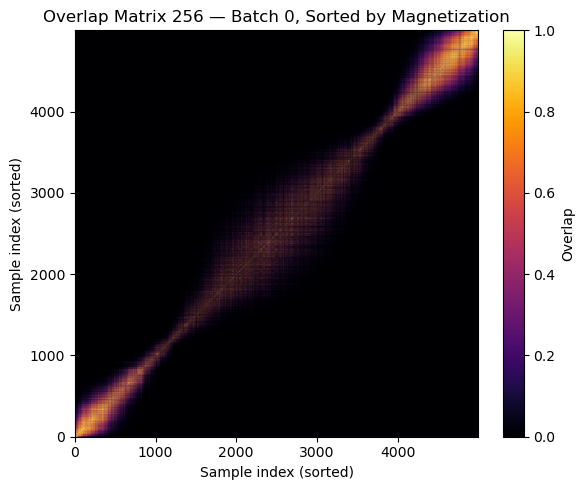

In [13]:
#  Configuration 
overlap_dir        = "overlap_batches_good16.2"
mag_labels_file    = "magnetizations_good16.1.npy"        # shape (N,)
samples_per_seed   = 50                      # known
batch_index        = 0                       # < change this to pick batch

#  Load files -
mag_labels = np.load(mag_labels_file).astype(np.float32)
overlap_files = sorted(
    f for f in os.listdir(overlap_dir)
    if f.startswith("overlap_batch_") and f.endswith(".npy")
)

num_batches = len(overlap_files)
total_samples = mag_labels.shape[0]
samples_per_batch = total_samples // num_batches

seeds_per_batch = samples_per_batch // samples_per_seed
print(f"Inferred: {seeds_per_batch} seeds per batch, {samples_per_batch} samples per batch")

#  Select batch -
if batch_index >= num_batches:
    raise ValueError(f"batch_index {batch_index} is out of range (only {num_batches} batches)")

start_sample = batch_index * samples_per_batch
end_sample   = start_sample + samples_per_batch

mag_batch = mag_labels[start_sample:end_sample]
sort_idx = np.argsort(mag_batch)

#  Load and sort overlap -
overlap_path = os.path.join(overlap_dir, overlap_files[batch_index])
overlap = np.load(overlap_path)
overlap = log(overlap)

overlap_sorted = overlap[np.ix_(sort_idx, sort_idx)]

#  Plot -
plt.figure(figsize=(6, 5))
im = plt.imshow(overlap_sorted, origin="lower", cmap="inferno", aspect="auto")
plt.colorbar(im, label="Overlap")
plt.title(f"Overlap Matrix 256 — Batch {batch_index}, Sorted by Magnetization")
plt.xlabel("Sample index (sorted)")
plt.ylabel("Sample index (sorted)")
plt.tight_layout()
plt.show()


In [19]:


#  Config 
overlap_dir = "overlap_batches_good16.2"
vae_means_file = "latent_means_good16.1.npy"
cluster_output_dir = "cluster_batches_good16.2"
n_clusters = 3

# Create output directories if they don't exist
os.makedirs(cluster_output_dir, exist_ok=True)

# Load full latent means
fitImgsVAE = np.load(vae_means_file)

# Get all overlap files
overlap_files = (glob.glob(os.path.join(overlap_dir, "overlap_batch_*.npy")))

n_plots = len(overlap_files)
cols = 4  # number of columns in grid
rows = (n_plots + cols - 1) // cols  # ceiling division for rows

fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3), squeeze=False)

for batch_idx, overlap_file in enumerate(overlap_files):
    print(f"Processing batch {batch_idx}: {overlap_file}")
    
    overlap = np.load(overlap_file)
    batch_size = overlap.shape[0]

    # Extract latent means for this batch
    start_idx = batch_idx * batch_size
    end_idx = start_idx + batch_size
    vae_batch = fitImgsVAE[start_idx:end_idx]

    assert vae_batch.shape[0] == batch_size, "Mismatch between overlap and latent mean batch sizes"

    # Perform Spectral Clustering
    clusters = SpectralClustering(
        n_clusters=n_clusters,
        affinity='precomputed',
        eigen_solver='arpack',
        eigen_tol=0,
        random_state=42
    ).fit_predict(overlap)

    # Save cluster assignments
    cluster_filename = os.path.join(cluster_output_dir, f"final_clusters_batch{batch_idx}.csv")
    np.savetxt(cluster_filename, clusters, delimiter=",", fmt="%d")

    # Plot on the respective subplot
    ax = axes[batch_idx // cols, batch_idx % cols]

    # If latent means are > 2D, just plot first 2 dims (no PCA)
    if vae_batch.shape[1] > 2:
        plot_data = vae_batch[:, :2]
    else:
        plot_data = vae_batch

    sc = ax.scatter(plot_data[:, 0], plot_data[:, 1], c=clusters, cmap='tab10', s=15, alpha=0.8)
    ax.set_title(f"Batch {batch_idx}")
    ax.set_xticks([])
    ax.set_yticks([])

# Remove unused subplots if any
for empty_idx in range(n_plots, rows * cols):
    fig.delaxes(axes[empty_idx // cols, empty_idx % cols])

plt.tight_layout()
plt.show()


Processing batch 0: overlap_batches_good16.2/overlap_batch_0.npy
Processing batch 1: overlap_batches_good16.2/overlap_batch_1.npy
Processing batch 2: overlap_batches_good16.2/overlap_batch_2.npy
Processing batch 3: overlap_batches_good16.2/overlap_batch_3.npy
Processing batch 4: overlap_batches_good16.2/overlap_batch_4.npy
Processing batch 5: overlap_batches_good16.2/overlap_batch_5.npy
Processing batch 6: overlap_batches_good16.2/overlap_batch_6.npy
Processing batch 7: overlap_batches_good16.2/overlap_batch_7.npy
Processing batch 8: overlap_batches_good16.2/overlap_batch_8.npy
Processing batch 9: overlap_batches_good16.2/overlap_batch_9.npy
Processing batch 10: overlap_batches_good16.2/overlap_batch_10.npy
Processing batch 11: overlap_batches_good16.2/overlap_batch_11.npy
Processing batch 12: overlap_batches_good16.2/overlap_batch_12.npy
Processing batch 13: overlap_batches_good16.2/overlap_batch_13.npy
Processing batch 14: overlap_batches_good16.2/overlap_batch_14.npy
Processing batc

ValueError: Found array with 0 sample(s) (shape=(0, 0)) while a minimum of 2 is required by SpectralClustering.

In [18]:

# - Config -
Tc = 2.269185314
overlap_dir = "overlap_batches_good16.2"
cluster_dir = "cluster_batches_good16.2"  # where your cluster CSVs are saved
temperature_labels = np.load("temperature_labels_good16.1.npy")
max_batches = 398


# - Load Overlap Files -
overlap_files = (glob.glob(os.path.join(overlap_dir, "overlap_batch_*.npy")))
n_batches = len(overlap_files)


# - Conductance Score -
def compute_conductance(overlap, clusters, target_cluster, eps=1e-15):
    scores = []
    for i in range(overlap.shape[0]):
        cluster_mask = (clusters == target_cluster)
        same_cluster = overlap[i, cluster_mask]
        all_total = np.sum(overlap[i])
        score = np.sum(same_cluster) / (all_total + eps)
        scores.append(score)
    return np.array(scores)

# - Heuristic: Find Magnetized Clusters -
def identify_magnetized_clusters_by_temperature(clusters, temps_batch, min_cluster_size=50):
    unique_clusters = np.unique(clusters)

    # Check that all clusters meet the size requirement
    for c in unique_clusters:
        count = np.sum(clusters == c)
        if count < min_cluster_size:
            print(f"[Outlier Rejection] Cluster {c} too small (size={count} < {min_cluster_size}). Skipping batch.")
            return None, None

    if len(unique_clusters) < 3:
        print(f"[Warning] Only {len(unique_clusters)} clusters. Skipping this batch.")
        return None, None

    # Compute average temps
    cluster_avg_temp = [
        (c, np.mean(temps_batch[clusters == c])) for c in unique_clusters
    ]

    sorted_by_temp = sorted(cluster_avg_temp, key=lambda x: x[1])
    magnetized = {sorted_by_temp[0][0], sorted_by_temp[1][0]}  # lowest 2
    disordered = sorted_by_temp[2][0]  # third lowest

    print(f"[Heuristic] Magnetized clusters: {magnetized}, Disordered cluster: {disordered}")
    return magnetized, disordered



# - Loop Over Batches -
results = []

start_idx = 0
for batch_idx, overlap_file in enumerate(overlap_files):
    if batch_idx >= max_batches:
        print(f"Stopping at max_batches={max_batches}")
        break
        
    overlap = np.load(overlap_file)
    batch_size = overlap.shape[0]
    end_idx = start_idx + batch_size

    # Load clusters for this batch
    cluster_file = os.path.join(cluster_dir, f"final_clusters_batch{batch_idx}.csv")
    clusters = np.loadtxt(cluster_file, delimiter=",", dtype=int)


    # Slice temperature labels
    temps_batch = np.array(temperature_labels[start_idx:end_idx])
    temps_scaled_batch = temps_batch / Tc

    
    # Infer clusters
    magnetized_clusters, disordered_cluster = identify_magnetized_clusters_by_temperature(clusters, temps_batch, min_cluster_size = 50)
    if magnetized_clusters is None or disordered_cluster is None:
        start_idx = end_idx
        print("DID SKIP")
        continue
    
    # Compute conductance scores
    magnetized_score = sum(
        compute_conductance(overlap, clusters, c)
        for c in magnetized_clusters
    )
    disordered_score = compute_conductance(overlap, clusters, disordered_cluster)

    # Store results
    batch_result = np.column_stack([
        temps_scaled_batch,
        1 - magnetized_score,
        1 - disordered_score
    ])
    results.append(batch_result)

    print(f"Batch {batch_idx}: Magnetized = {magnetized_clusters}, Disordered = {disordered_cluster}")
    start_idx = end_idx  # move forward

# - Save + Plot -
final_result = np.vstack(results)
np.savetxt("conductance_scores_good32.1.csv", final_result,
           delimiter=",",
           header="Temp_Scaled,1-Magnetized_Score,1-Disordered_Score",
           comments='',
           fmt="%.4f,%.6f,%.6f")

# - Plot -
plt.figure(figsize=(8, 6))
plt.scatter(final_result[:, 0], final_result[:, 1], color='red', s=12, alpha=0.7, label='Magnetized Clusters')
plt.scatter(final_result[:, 0], final_result[:, 2], color='blue', s=12, alpha=0.7, label='Disordered Cluster')
plt.axvline(1.0, color='orange', linewidth=2, label='Tc')
plt.xlabel("Temperature / Tc")
plt.ylabel("1 - Conductance")
plt.title("Cluster Affiliation vs. Temperature")
# plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


[Heuristic] Magnetized clusters: {np.int64(0), np.int64(2)}, Disordered cluster: 1
Batch 0: Magnetized = {np.int64(0), np.int64(2)}, Disordered = 1
[Heuristic] Magnetized clusters: {np.int64(0), np.int64(1)}, Disordered cluster: 2
Batch 1: Magnetized = {np.int64(0), np.int64(1)}, Disordered = 2
[Heuristic] Magnetized clusters: {np.int64(0), np.int64(1)}, Disordered cluster: 2
Batch 2: Magnetized = {np.int64(0), np.int64(1)}, Disordered = 2
[Heuristic] Magnetized clusters: {np.int64(1), np.int64(2)}, Disordered cluster: 0
Batch 3: Magnetized = {np.int64(1), np.int64(2)}, Disordered = 0
[Heuristic] Magnetized clusters: {np.int64(0), np.int64(2)}, Disordered cluster: 1
Batch 4: Magnetized = {np.int64(0), np.int64(2)}, Disordered = 1
[Heuristic] Magnetized clusters: {np.int64(0), np.int64(2)}, Disordered cluster: 1
Batch 5: Magnetized = {np.int64(0), np.int64(2)}, Disordered = 1
[Heuristic] Magnetized clusters: {np.int64(0), np.int64(1)}, Disordered cluster: 2
Batch 6: Magnetized = {np.int

IndexError: boolean index did not match indexed array along axis 0; size of axis is 0 but size of corresponding boolean axis is 5000

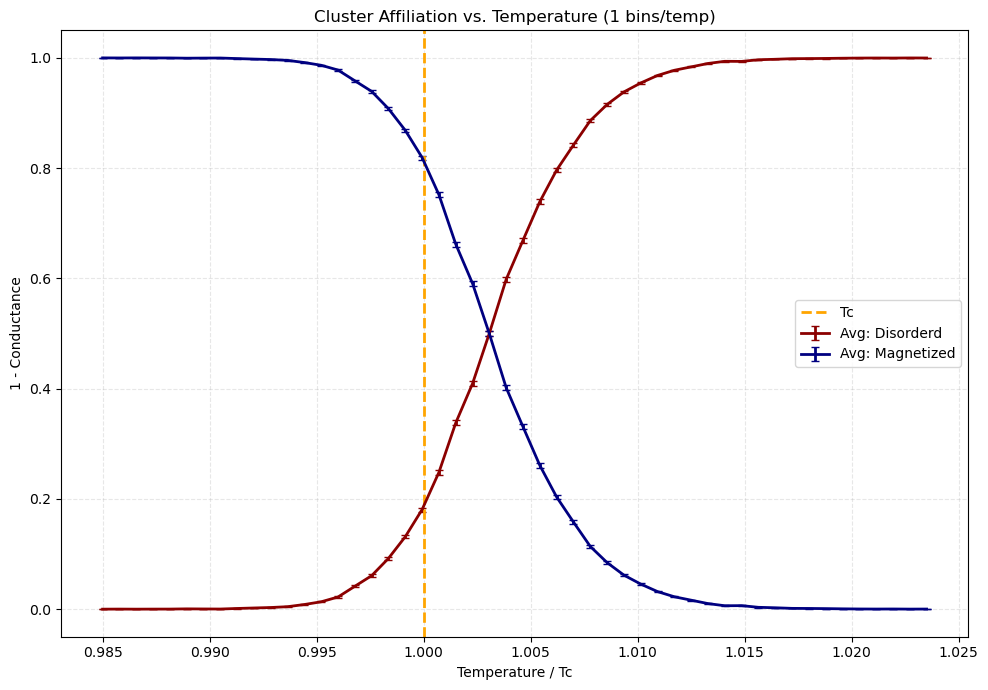

Saved to conductance_binned_good256.1.csv


In [12]:
import numpy as np
import matplotlib.pyplot as plt

#  Configuration 
bins_per_temp = 1  # You can increase this
save_filename = "conductance_binned_good256.1.csv"

#  Input Data 
temps = final_result[:, 0]
magnetized_vals = final_result[:, 1]
disordered_vals = final_result[:, 2]

unique_temps = np.unique(temps)
binned_temp = []
binned_mag = []
binned_dis = []
binned_mag_err = []
binned_dis_err = []

#  Binning + Statistics 
for T in unique_temps:
    mask = temps == T
    indices = np.where(mask)[0]

    np.random.shuffle(indices)
    sub_bins = np.array_split(indices, bins_per_temp)

    for sub in sub_bins:
        if len(sub) > 0:
            binned_temp.append(T)
            binned_mag.append(np.mean(magnetized_vals[sub]))
            binned_dis.append(np.mean(disordered_vals[sub]))
            binned_mag_err.append(np.std(magnetized_vals[sub]) / np.sqrt(len(sub)))
            binned_dis_err.append(np.std(disordered_vals[sub]) / np.sqrt(len(sub)))

#  Convert to Arrays 
binned_temp = np.array(binned_temp)
binned_mag = np.array(binned_mag)
binned_dis = np.array(binned_dis)
binned_mag_err = np.array(binned_mag_err)
binned_dis_err = np.array(binned_dis_err)

#  Numerical Derivatives 
dmag_dT = np.gradient(binned_mag, binned_temp)
ddis_dT = np.gradient(binned_dis, binned_temp)

#  Plotting 
plt.figure(figsize=(10, 7))
plt.errorbar(binned_temp, binned_mag, yerr=binned_mag_err, color='darkred', linewidth=2, label='Avg: Disorderd', capsize=3)
plt.errorbar(binned_temp, binned_dis, yerr=binned_dis_err, color='navy', linewidth=2, label='Avg: Magnetized', capsize=3)

plt.axvline(1.0, color='orange', linewidth=2, linestyle='--', label='Tc')
plt.xlabel("Temperature / Tc")
plt.ylabel("1 - Conductance")
plt.title(f"Cluster Affiliation vs. Temperature ({bins_per_temp} bins/temp)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#  Saving Output 
output_data = np.column_stack([
    binned_temp,
    binned_mag,
    binned_mag_err,
    binned_dis,
    binned_dis_err
])
np.savetxt(
    save_filename,
    output_data,
    delimiter=",",
    header="temp_scaled,magnetized_avg,magnetized_se,disordered_avg,disordered_se",
    comments=''
)
print(f"Saved to {save_filename}")



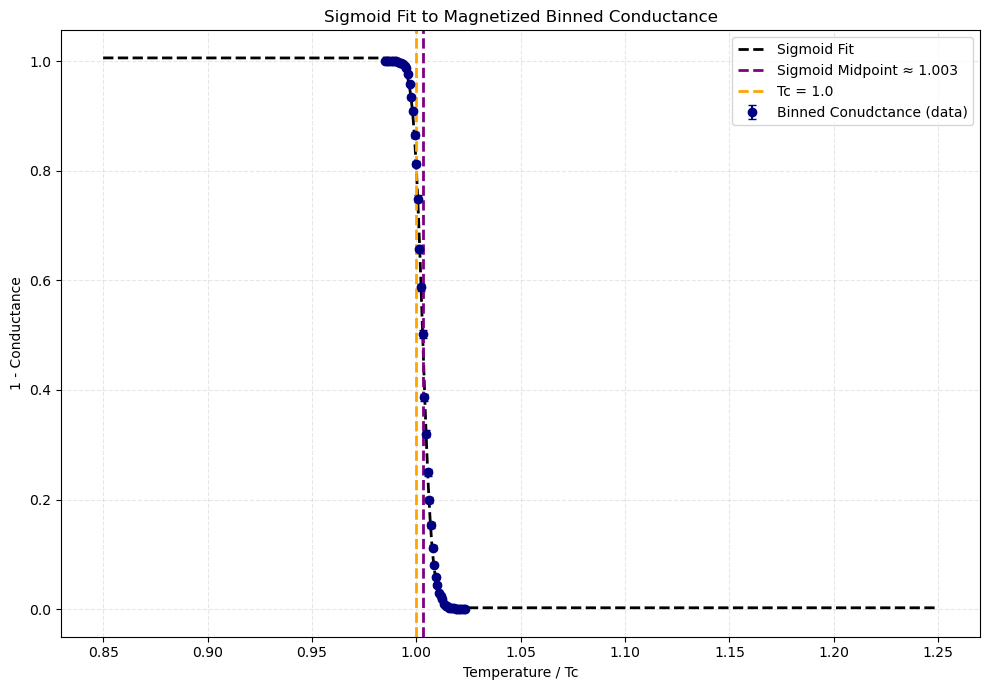

Sigmoid fit parameters:
  A = 1.0033, k = -459.2115, T0 = 1.0030, C = 0.0025


In [41]:
from scipy.optimize import curve_fit

#  Sigmoid Function 
def sigmoid(T, A, k, T0, C):
    return A / (1 + np.exp(-k * (T - T0))) + C

#  Fit Sigmoid to Disordered Curve 
p0 = [1.0, 10.0, 1.0, 0.0]  # [amplitude, steepness, center, offset]
params, _ = curve_fit(sigmoid, binned_temp, binned_dis, p0=p0)
A_fit, k_fit, T0_fit, C_fit = params

#  Adjustable Plot Range 
# Manually set the fit range (in scaled temperature)
fit_range = (0.85, 1.25)  # < ADJUST HERE
T_fit = np.linspace(fit_range[0], fit_range[1], 1000)
disordered_fit = sigmoid(T_fit, *params)

#  Plot 
plt.figure(figsize=(10, 7))
plt.errorbar(binned_temp, binned_dis, yerr=binned_dis_err, fmt='o', color='navy',
             label='Binned Conudctance (data)', capsize=3)
plt.plot(T_fit, disordered_fit, color='black', linestyle='--', linewidth=2, label='Sigmoid Fit')

plt.axvline(T0_fit, color='purple', linestyle='--', linewidth=2, label=f'Sigmoid Midpoint ≈ {T0_fit:.3f}')
plt.axvline(1.0, color='orange', linestyle='--', linewidth=2, label='Tc = 1.0')

plt.xlabel("Temperature / Tc")
plt.ylabel("1 - Conductance")
plt.title("Sigmoid Fit to Magnetized Binned Conductance")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#  Print Parameters 
print(f"Sigmoid fit parameters:")
print(f"  A = {A_fit:.4f}, k = {k_fit:.4f}, T0 = {T0_fit:.4f}, C = {C_fit:.4f}")


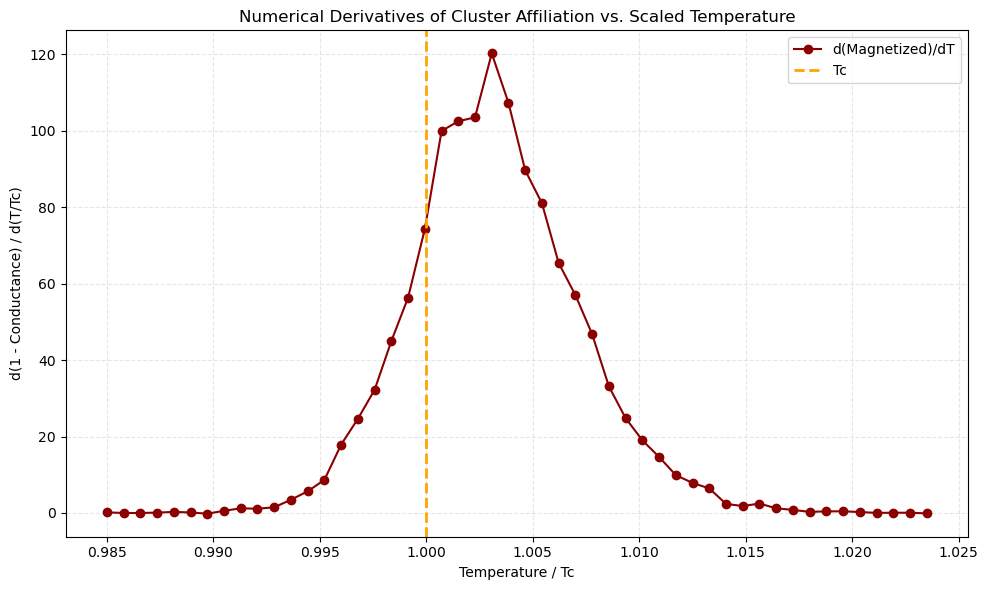

In [13]:
#  Plot: Numerical Derivatives 
plt.figure(figsize=(10, 6))
plt.plot(binned_temp, dmag_dT, '-o', color='darkred', label='d(Magnetized)/dT')
# plt.plot(binned_temp, ddis_dT, '-o', color='navy', label='d(Disordered)/dT')
plt.axvline(1.0, color='orange', linestyle='--', linewidth=2, label='Tc')

plt.xlabel("Temperature / Tc")
plt.ylabel("d(1 - Conductance) / d(T/Tc)")
plt.title("Numerical Derivatives of Cluster Affiliation vs. Scaled Temperature")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


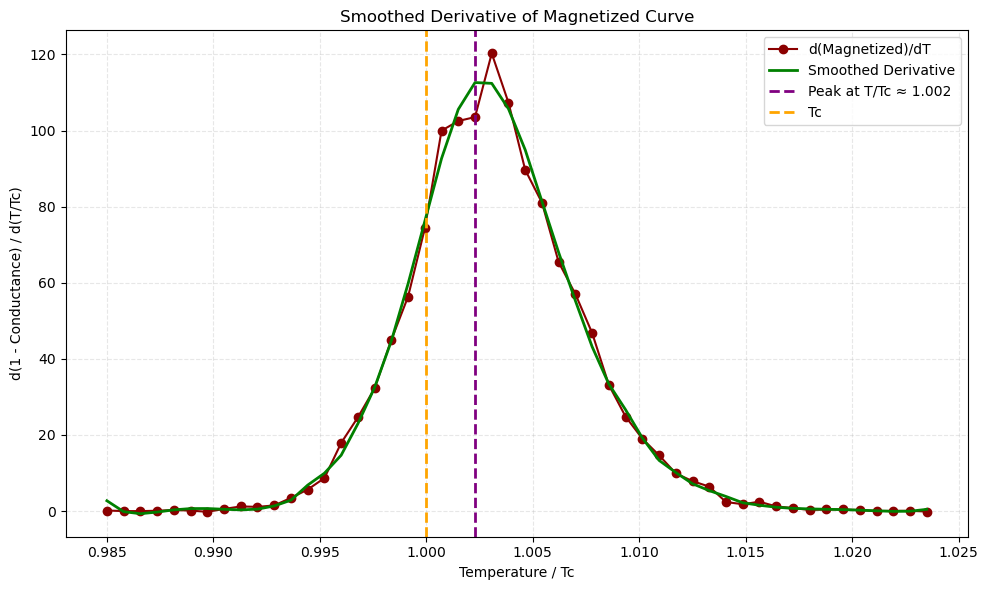

Saved to conductance_deriv_good256.1.csv


In [15]:
from scipy.signal import savgol_filter

save_filename = "conductance_deriv_good256.1.csv"


#  Savitzky-Golay Derivative 
# Ensure window length is valid: odd and <= len(data)
window_length = 21
polyorder = 7

# Apply smoothing first, then compute derivative
smoothed_mag = savgol_filter(binned_mag, window_length=window_length, polyorder=polyorder)
dmag_dT_smooth = savgol_filter(binned_mag, window_length=window_length, polyorder=polyorder, deriv=1, delta=np.mean(np.diff(binned_temp)))

#  Find Peak in Derivative 
peak_index = np.argmax(dmag_dT_smooth)
peak_temp = binned_temp[peak_index]
peak_val = dmag_dT_smooth[peak_index]

#  Plot: Smoothed Derivative 
plt.figure(figsize=(10, 6))
plt.plot(binned_temp, dmag_dT, '-o', color='darkred', label='d(Magnetized)/dT')
plt.plot(binned_temp, dmag_dT_smooth, color='green', linewidth=2, label='Smoothed Derivative')
plt.axvline(peak_temp, color='purple', linestyle='--', linewidth=2, label=f'Peak at T/Tc ≈ {peak_temp:.3f}')
plt.axvline(1.0, color='orange', linestyle='--', linewidth=2, label='Tc')

plt.xlabel("Temperature / Tc")
plt.ylabel("d(1 - Conductance) / d(T/Tc)")
plt.title("Smoothed Derivative of Magnetized Curve")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#  Save Output 
output_data = np.column_stack([
    binned_temp,
    binned_mag,
    binned_mag_err,
    binned_dis,
    binned_dis_err
])
# np.savetxt(
#     save_filename,
#     output_data,
#     delimiter=",",
#     header="temp_scaled,magnetized_avg,magnetized_se,disordered_avg,disordered_se",
#     comments=''
# )
print(f"Saved to {save_filename}")


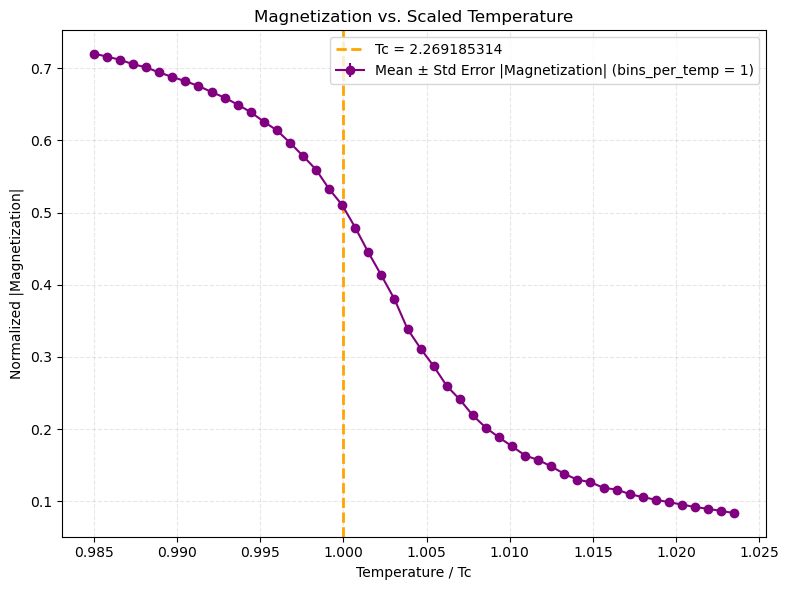

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

#  Load saved data 
magnetizations = np.load("magnetizations_good256.1.npy")
magnetizations = magnetizations
temps = np.load("temperature_labels_good256.1.npy")

#  Constants 
Tc = 2.269185314
L = 256  # lattice size
bins_per_temp = 1  # you can increase for finer resolution

#  Normalize and scale 
temps = np.array(temps)
temps = temps[:2000000]
temps_scaled = temps / Tc
magnetization_norm = np.abs(magnetizations) / (L * L)

#  Bin magnetization per unique temperature 
unique_temps = np.unique(temps)
bin_means, bin_stds, bin_counts, bin_centers = [], [], [], []

for T in unique_temps:
    mask = temps == T
    indices = np.where(mask)[0]
    np.random.shuffle(indices)

    sub_bins = np.array_split(indices, bins_per_temp)
    for sub in sub_bins:
        if len(sub) > 0:
            m_vals = magnetization_norm[sub]
            bin_means.append(np.mean(m_vals))
            bin_stds.append(np.std(m_vals))
            bin_counts.append(len(m_vals))
            bin_centers.append(T / Tc)  # Scaled temp

#  Convert to arrays and sort 
bin_centers = np.array(bin_centers)
bin_means = np.array(bin_means)
bin_stds = np.array(bin_stds)
bin_counts = np.array(bin_counts)

sort_idx = np.argsort(bin_centers)
bin_centers = bin_centers[sort_idx]
bin_means = bin_means[sort_idx]
bin_stds = bin_stds[sort_idx]
bin_counts = bin_counts[sort_idx]

#  Standard error 
bin_stderr = bin_stds / np.sqrt(bin_counts)

#  Plot 
plt.figure(figsize=(8, 6))
plt.errorbar(bin_centers, bin_means, yerr=bin_stderr, fmt='-o', color='purple',
             label=f'Mean ± Std Error |Magnetization| (bins_per_temp = {bins_per_temp})')

# Add vertical line at Tc
plt.axvline(1.0, color='orange', linestyle='--', linewidth=2, label='Tc = 2.269185314')

plt.xlabel("Temperature / Tc")
plt.ylabel("Normalized |Magnetization|")
plt.title("Magnetization vs. Scaled Temperature")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


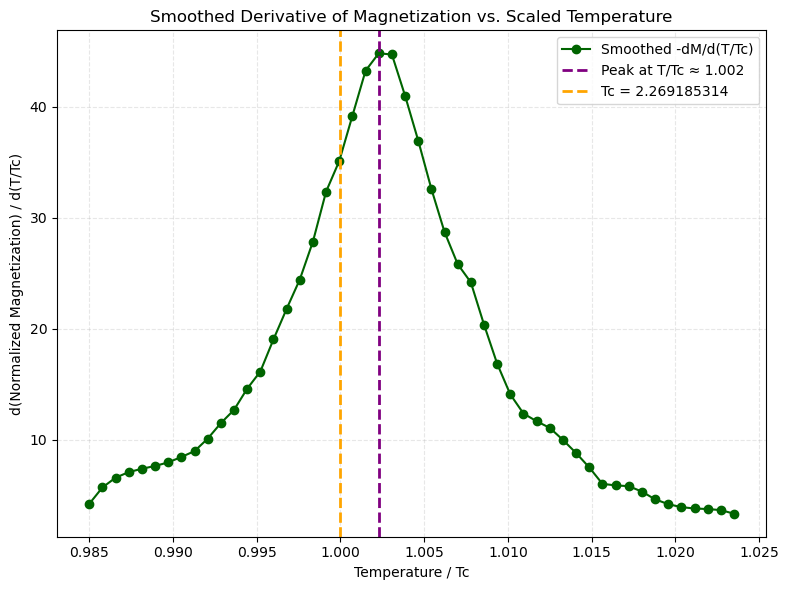

Data saved to magnetization_smoothed_derivative.csv
Peak derivative at T/Tc = 1.0023 with value -44.7862


In [45]:
#  Savitzky-Golay smoothing and derivative 
window_length = 13
polyorder = 5

# Smooth magnetization
smoothed_mag = savgol_filter(bin_means, window_length=window_length, polyorder=polyorder)

# Compute smoothed first derivative (dM/dT)
dM_dT_smooth = savgol_filter(bin_means, window_length=window_length, polyorder=polyorder,
                             deriv=1, delta=np.mean(np.diff(bin_centers)))

#  Find peak of derivative 
peak_index = np.argmax(-dM_dT_smooth)  # negative because magnetization decreases with T
peak_temp = bin_centers[peak_index]
peak_val = dM_dT_smooth[peak_index]

#  Plot smoothed derivative 
plt.figure(figsize=(8, 6))
plt.plot(bin_centers, -dM_dT_smooth, '-o', color='darkgreen', label='Smoothed -dM/d(T/Tc)')
plt.axvline(peak_temp, color='purple', linestyle='--', linewidth=2, label=f'Peak at T/Tc ≈ {peak_temp:.3f}')
plt.axvline(1.0, color='orange', linestyle='--', linewidth=2, label='Tc = 2.269185314')

plt.xlabel("Temperature / Tc")
plt.ylabel("d(Normalized Magnetization) / d(T/Tc)")
plt.title("Smoothed Derivative of Magnetization vs. Scaled Temperature")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#  Save data 
output_array = np.column_stack([
    bin_centers,
    smoothed_mag,
    dM_dT_smooth
])
header = "temp_scaled,smoothed_magnetization,smoothed_derivative"
np.savetxt("mag_deriv_good256.1.csv", output_array, delimiter=",", header=header, comments='')

print(f"Data saved to magnetization_smoothed_derivative.csv")
print(f"Peak derivative at T/Tc = {peak_temp:.4f} with value {peak_val:.4f}")
